> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# **IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing**

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Business Context: Hotel Bookings

### Dataset Description:

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## **Task 1. Setup and Data Loading**

Instructions:

🔧 1.1. Import `pandas`, `seaborn`, and `matplotlib.pyplot`.

🔧 1.2. Load the dataset from this URL:
  https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv

🔧 1.3. Display some sample rows to confirm it loaded correctly.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/hotels.csv')

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## **Task 2. Stakeholder and Business Context**

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### 🔧 Please answer the following:

2.1. Who are the key stakeholders for this dataset?\
2.2. What goals might each stakeholder have?\
2.3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
2.1. Hotel managers, hotel staff, and customers.

2.2. Hotel managers want the hotel to make more money and have more rooms booked.
Hotel staff want to know how many customers will come, so they can prepare for check-in.
Customers want to book a room with a good price and have a good hotel experience.

2.3. The hotel wants to know what kinds of bookings are more likely to be canceled. This information can help the hotel reduce empty rooms and make better decisions about room prices and bookings.




## **Task 3. Explore Data Structure and Quality**

### Business framing:

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.



### 🔧 3.1 - 3.3. Use at least 3 techniques to examine structure and quality:
  - Summary info, summary statistics
  - Data Types
  - Missing value checks
  - Duplicate row checks
  - Detect Outliers



In [7]:
# 🔧 3.1. Display basic information about the DataFrame (data types, non-null counts)
display(df.info())

# 🔧 3.2. Display descriptive statistics for numerical columns
display(df.describe())

# 🔧 3.3. Check for missing values
display(df.isnull().sum())

# Check for duplicate rows
display(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


np.int64(31994)

### 🔧 Please answer the following:

3.4. What structural issues (e.g., missing values, incorrectly inferred data types, duplicates, outliers, or formatting problems) did you find?

3.5. What actions would you recommend to fix this structural issue?



### ✍️ Your Response: 🔧
3.4. I found some empty data. For example, country has 488 empty values. agent and company also have many empty values. children has 4 empty values. Also, there are some duplicate rows in the data. The biggest lead_time is 737 days. I think this number is very big, so we may need to check it.

3.5. For country, we can fill the empty values with “Unknown.” For agent and company, we can fill the empty values with 0, because some customers may not use an agent or company to book a room. For children, we can fill the empty values with 0. We can delete the duplicate rows. For the very big numbers, we should check them first. If they are not wrong, we can keep them.



## **Task 4. Univariate Analysis**

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### 🔧 4.1 - 4.3 Select at least 3 individual variables to explore
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)
- Use plots and summaries to describe the distribution





Distribution of Canceled vs. Not Canceled bookings:


,count
is_canceled,
0,75166
1,44224


,proportion
is_canceled,
0,62.958372
1,37.041628


/tmp/ipykernel_824/2552267794.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='viridis')


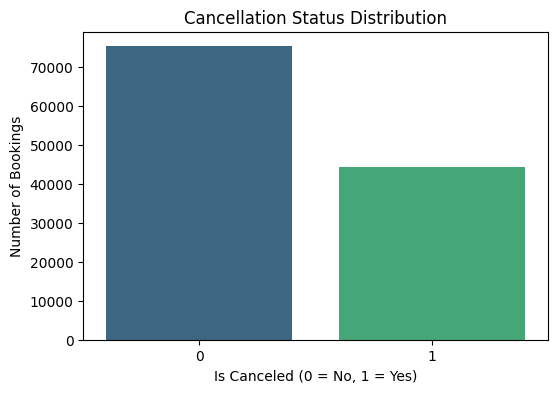


Distribution of Hotel Types:


,count
hotel,
City Hotel,79330
Resort Hotel,40060


,proportion
hotel,
City Hotel,66.446101
Resort Hotel,33.553899


/tmp/ipykernel_824/2552267794.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hotel', data=df, palette='magma')


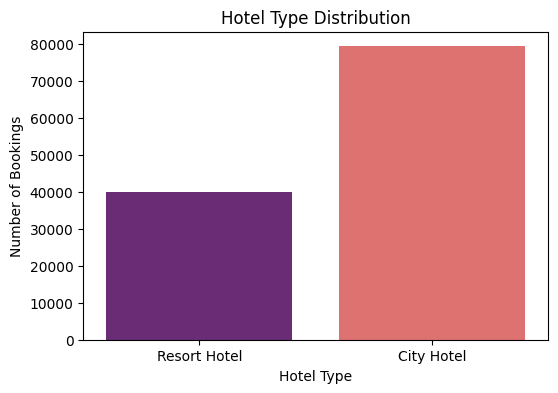


Summary Statistics for Lead Time:


,lead_time
count,119390.000000
mean,104.011416
std,106.863097
min,0.000000
25%,18.000000
50%,69.000000
75%,160.000000
max,737.000000


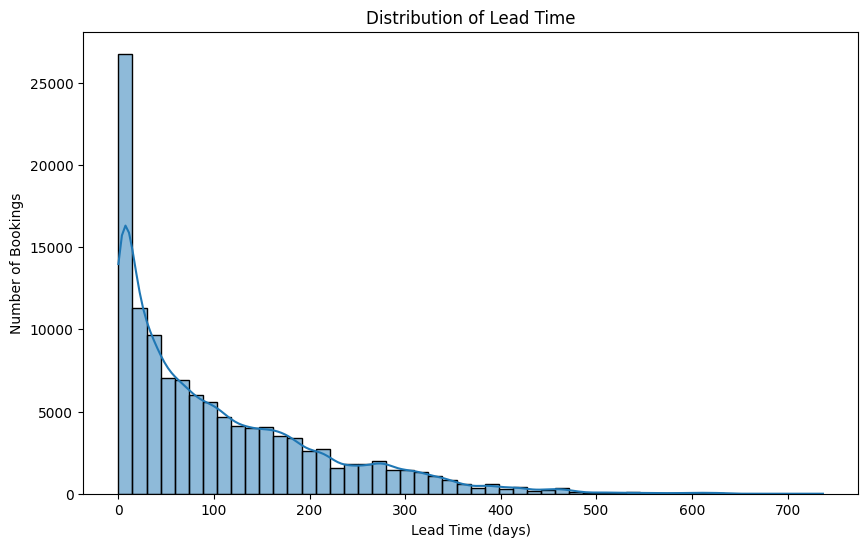

In [8]:
# 🔧 4.1. Your code for univariate analysis (e.g., plots, value counts) for variable 1
# Variable 1: is_canceled
print("Distribution of Canceled vs. Not Canceled bookings:")
display(df['is_canceled'].value_counts())
display(df['is_canceled'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='viridis')
plt.title('Cancellation Status Distribution')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Number of Bookings')
plt.show()

# 🔧 4.2. Your code for univariate analysis (e.g., plots, value counts) for variable 2
# Variable 2: hotel
print("\nDistribution of Hotel Types:")
display(df['hotel'].value_counts())
display(df['hotel'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='hotel', data=df, palette='magma')
plt.title('Hotel Type Distribution')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

# 🔧 4.3. Your code for univariate analysis (e.g., plots, value counts) for variable 3
# Variable 3: lead_time
print("\nSummary Statistics for Lead Time:")
display(df['lead_time'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Bookings')
plt.show()

### 🔧 Please answer the following:

4.4. Variable 1 - What did you explore and what did you find?

4.5. Variable 2 - What did you explore and what did you find?

4.6. Variable 3 - What did you explore and what did you find?

### ✍️ Your Response: 🔧

4.4. Variable 1 summary and insights

I looked at is_canceled. There are 75,166 bookings that were not canceled, about 63%. There are 44,224 canceled bookings, about 37%. This means many customers canceled their bookings.

4.5. Variable 2 summary and insights

I looked at hotel. City Hotel has 79,330 bookings, about 66%. Resort Hotel has 40,060 bookings, about 34%. City Hotel has more bookings than Resort Hotel.

4.6. Variable 3 summary and insights

I looked at lead_time. The average booking time is about 104 days before arrival. The middle number is 69 days. Most people book less than 160 days before they arrive. The biggest number is 737 days. The chart shows that many people book close to their arrival date.



## **Task 5. Bivariate Analysis**

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

###  🔧 5.1 - 5.2 Choose 2 relevant variable pairs to examine
- such as (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships. If the relationship or trend is not cleanly visible, then change the type of chart.
- Interpret what these relationships could mean for the hotel business





/tmp/ipykernel_824/4094887933.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_lead_time = df.groupby(lead_time_bins)['is_canceled'].mean().reset_index()
/tmp/ipykernel_824/4094887933.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lead_time', y='is_canceled', data=cancellation_by_lead_time, palette='GnBu_d')


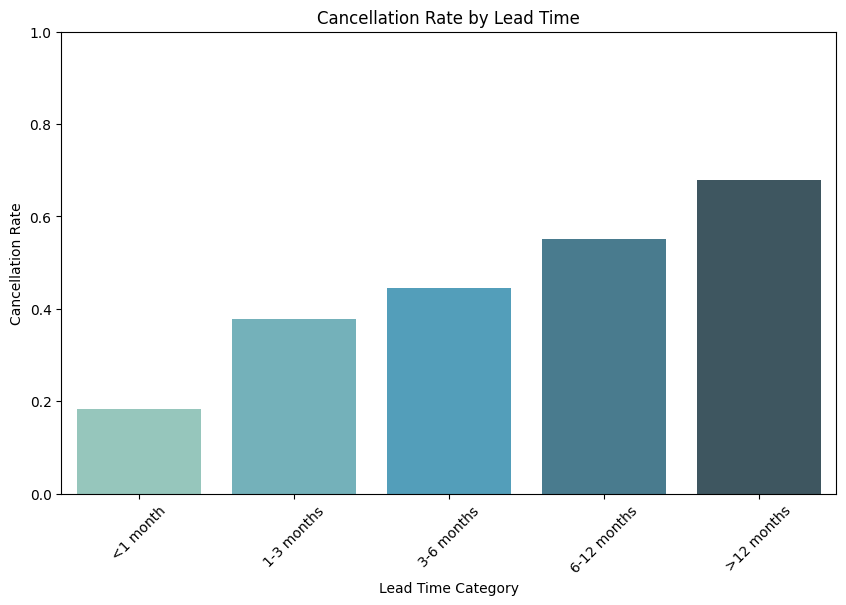

/tmp/ipykernel_824/4094887933.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_type', y='is_canceled', data=cancellation_by_customer_type, palette='magma')


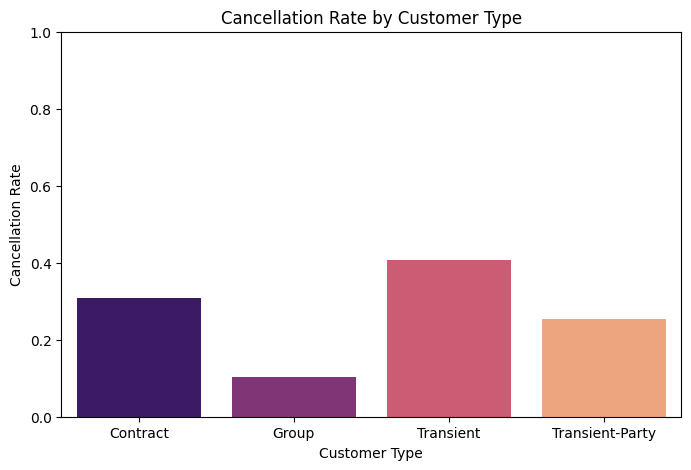

In [9]:
# 🔧 5.1 Your code to analyze variable relationships (e.g., scatterplots, grouped bars)
# Relationship 1: lead_time vs. is_canceled

# Create bins for lead_time to analyze cancellation rates across different lead times
lead_time_bins = pd.cut(df['lead_time'], bins=[0, 30, 90, 180, 365, df['lead_time'].max()],
                        labels=['<1 month', '1-3 months', '3-6 months', '6-12 months', '>12 months'],
                        right=False)

cancellation_by_lead_time = df.groupby(lead_time_bins)['is_canceled'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='lead_time', y='is_canceled', data=cancellation_by_lead_time, palette='GnBu_d')
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time Category')
plt.ylabel('Cancellation Rate')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for cancellation rate
plt.xticks(rotation=45)
plt.show()

# 🔧 5.2 Your code to analyze variable relationships (e.g., scatterplots, grouped bars)
# Relationship 2: customer_type vs. is_canceled

cancellation_by_customer_type = df.groupby('customer_type')['is_canceled'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='customer_type', y='is_canceled', data=cancellation_by_customer_type, palette='magma')
plt.title('Cancellation Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate')
plt.ylim(0, 1) # Set y-axis limit from 0 to 1 for cancellation rate
plt.show()

### 🔧 Please answer the following:

5.3. Relationship 1 - What did you analyze and what insights did you find?

5.4. Relationship 2 - What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧

5.3. Relationship 1

I put lead time and cancellation together to see the result. It looks like people who book earlier are more likely to cancel later. I think maybe their plan changes after they book the room, so they cancel it.

5.4. Relationship 2

I also looked at customer type and cancellation. Transient customers cancel the most. Group customers cancel the least. So the hotel may need to pay more attention to Transient customers because they cancel more often.

## **Task 6. Problem Complexity and Analytics Framing**

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

Choose one insight from your earlier analysis. Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)




### 🔧 Please answer the following:

6.1. What was your selected insight?

6.2. What kind of complexity does it involve?

6.3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧

6.1. I found that people who book much earlier cancel more.

6.2. I think this is variability. Different people may have different plans, so not everyone will cancel.

6.3. Predictive analytics may help with this. The hotel can look at the booking time and try to see which customers may cancel. This can help the hotel plan for empty rooms.



## **Task 7. Reflections, Final Takeaways and Recommendations**

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### 🔧 Please answer the following:

7.1. What patterns or trends stood out?

7.2. How do they connect to stakeholder goals?

7.3. What recommendation would you make based on this analysis?

7.4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

7.1. I found that people who book earlier may cancel more. Also, Transient customers cancel more than other customers.

7.2. This is important for the hotel. If many people cancel, some rooms may be empty and the hotel may lose money.

7.3. I think the hotel can send a message to people who booked early. The message can ask if they still need the room. This may help the hotel know which rooms may be empty.

7.4. This lab connects to my learning outcomes because I cleaned the hotel data and checked missing values and duplicate rows before doing the analysis. I also used the data to find which bookings may be canceled more. For example, people who book early may cancel more. This is a simple way to use data to help predict a result.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown/comment questions are answered thoughtfully in your own words
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas

In [10]:
!jupyter nbconvert --to html "assignment_05_Gong Linlin.ipynb"

[NbConvertApp] Converting notebook assignment_05_Gong Linlin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 510479 bytes to assignment_05_Gong Linlin.html
